In [72]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [73]:
df = pd.read_csv('injection_molding_predictive_maintenance.csv')
df.drop(columns=['timestamp'], inplace=True)
df.head(1)

,mold_id,mold_name,material_name,machine_tonnage,cycle_number,hopper_temp,nozzle_temp,H1,H2,H3,...,total_cycle_time,Hopper_State,Barrel_Heater_State,Screw_State,Injection_Unit_State,Hydraulic_System_State,Clamp_Unit_State,Mold_State,Cooling_System_State,Ejector_System_State
0,TL-2026-ABS-0892,Smart Router Enclosure (Top Cover) - 2 Cavity,"ABS (Flame Retardant, Medium Flow)",180,1,45.4,230,225,215,199,...,24.304,0,0,0,0,0,0,0,0,0


In [74]:
target = ['Hopper_State','Barrel_Heater_State', 'Screw_State', 'Injection_Unit_State','Hydraulic_System_State', 
               'Clamp_Unit_State', 'Mold_State','Cooling_System_State', 'Ejector_System_State']  
sensor = [i for i in df.columns if i not in target]
sensor.remove('mold_name')
sensor.remove('mold_id')
sensor.remove('material_name')
len(sensor)

41

In [75]:
def find_correlation(corr, threshold=0.95):
    """Iteratively drop the more globally-redundant column of the most-correlated
    remaining pair, until no pair exceeds threshold. Avoids over-pruning chains."""
    corr = corr.abs().copy()
    vals = corr.values.copy()
    np.fill_diagonal(vals, 0)  # ignore self-correlation
    corr = pd.DataFrame(vals, index=corr.index, columns=corr.columns)
    to_drop = []
    while True:
        max_corr = corr.values.max()
        if max_corr <= threshold or corr.shape[0] <= 1:
            break
        i, j = np.unravel_index(np.argmax(corr.values), corr.shape)
        col_i, col_j = corr.index[i], corr.columns[j]
        # drop whichever has the higher average correlation with everything else remaining
        drop_col = col_i if corr[col_i].mean() > corr[col_j].mean() else col_j
        to_drop.append(drop_col)
        corr = corr.drop(index=drop_col, columns=drop_col)
    return to_drop

# correlation-based pruning of redundant raw sensor columns
corr = df[sensor].corr()
to_drop = find_correlation(corr, threshold=0.95)
kept_numeric_cols = [c for c in sensor if c not in to_drop]
df.drop(columns=to_drop, inplace=True)
print(f"Dropped {len(to_drop)} redundant (|r|>0.95) columns, kept {len(kept_numeric_cols)}:")
print(kept_numeric_cols)

Dropped 25 redundant (|r|>0.95) columns, kept 16:
['cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed3', 'vp_transition', 'holding_pressure', 'back_pressure', 'decompression_speed', 'decompression_distance', 'cushion_position', 'mold_protection_pressure', 'ejection_stroke', 'part_weight', 'mould_close_time', 'clamp_close_position']


## Train Test Split

In [76]:
import pandas as pd
 
train_list = []
val_list = []
test_list = []
 
# Sort first
df = df.sort_values(['mold_id', 'cycle_number']).reset_index(drop=True)
 
for mold_id, group in df.groupby('mold_id'):
 
    n = len(group)
 
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
 
    train_list.append(group.iloc[:train_end])
    val_list.append(group.iloc[train_end:val_end])
    test_list.append(group.iloc[val_end:])
 
train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)
 
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")


Train: (28000, 28)
Validation: (6000, 28)
Test: (6000, 28)


## Feature Engineering

In [77]:
window = 5
temp_pressure  = ['hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed3','holding_pressure', 'back_pressure', 'decompression_speed','mold_protection_pressure', 'ejection_stroke', 'part_weight', 'mould_close_time']

def add_engineered_features(data, window=window, temp_pressure=temp_pressure, kept_numeric_cols=kept_numeric_cols):
    data = data.sort_values(['mold_id', 'cycle_number']).reset_index(drop=True)
    grp = data.groupby('mold_id')

    # rolling mean & std
    roll_mean = grp[temp_pressure].rolling(window, min_periods=1).mean().droplevel(0)
    roll_mean.columns = [f'{c}_roll_mean' for c in temp_pressure]

    roll_std = grp[temp_pressure].rolling(window, min_periods=1).std().droplevel(0)
    roll_std.columns = [f'{c}_roll_std' for c in temp_pressure]

    # delta
    delta = grp[kept_numeric_cols].diff()
    delta.columns = [f'{c}_delta' for c in kept_numeric_cols]

    eng = pd.concat([roll_mean, roll_std, delta], axis=1).sort_index().fillna(0.0)
    return pd.concat([data, eng], axis=1)

train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (28000, 66)
Validation: (6000, 66)
Test: (6000, 66)


In [78]:
#ohe on mold id
def add_mold_dummies(data):
    enc = pd.get_dummies(data['mold_id'], prefix='mold_id', dtype=int)
    return pd.concat([enc,data], axis=1)

train_df = add_mold_dummies(train_df)
val_df = add_mold_dummies(val_df)
test_df = add_mold_dummies(test_df)

In [79]:
# scaling numeric features
scaler = StandardScaler()
id_cat_cols = ['mold_id', 'mold_name', 'material_name']
mold_dummy_cols = [c for c in train_df.columns if c.startswith('mold_id_')]

exclude_cols = id_cat_cols + target + mold_dummy_cols

numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [80]:
train_df.drop(columns=['mold_id','mold_name','material_name'],inplace=True)
val_df.drop(columns=['mold_id','mold_name','material_name'],inplace=True)
test_df.drop(columns=['mold_id','mold_name','material_name'],inplace=True)

In [81]:
def reorder_target_last(data, target=target):
    cols = [c for c in data.columns if c not in target] + target
    return data[cols]

train_df = reorder_target_last(train_df)
val_df = reorder_target_last(val_df)
test_df = reorder_target_last(test_df)

X_train, y_train = train_df.drop(columns=target), train_df[target]
X_val, y_val = val_df.drop(columns=target), val_df[target]
X_test, y_test = test_df.drop(columns=target), test_df[target]

## Anomaly / Novelty Detection

**One model per algorithm, or 9 (one per component)?** Go with **one global detector per algorithm**, trained on rows where *all 9* component states are healthy (`== 0`). Reasoning:

- These algorithms (Isolation Forest, ECOD, COPOD, LOF, Autoencoder) score how far a row's *whole* sensor profile deviates from the healthy manifold. They aren't supervised on which component failed, so there's no benefit to training 9 copies unless you also give each copy a different, component-specific feature subset.
- "Healthy for component X" still includes cycles that are unhealthy in other components (unless you filter those out too, which fragments an already-small fault dataset 9 ways for no real gain).
- A single anomaly score answers "is this cycle abnormal at all" — exactly what novelty detection is for. Figuring out *which* component is at fault is a separate supervised multi-label problem for later, not something these unsupervised detectors are built to disentangle.

So below: filter `X_train`/`y_train` to rows where all 9 targets are 0, fit each detector on that healthy-only subset, and evaluate on `val_df` (mixed healthy/unhealthy) using "any target == 1" as the ground-truth anomaly label.

## Per-Subsystem Anomaly Detection (9 targets)

Instead of one global anomaly score, fit **5 algorithms (Isolation Forest, ECOD, COPOD, LOF, Autoencoder) independently for each of the 9 subsystem targets**. For each target column `col`:

- Train only on `train_df` rows where `col == 0` (healthy for *that* subsystem specifically -- other subsystems may be unhealthy in the same row).
- Feature set: same columns used everywhere else in the pipeline (`train_df`/`val_df`/`test_df` minus the 9 target columns).
- Score **every** row of `train_df`, `val_df`, `test_df` and store it as a new column `f'{col}_{algo}_score'` (45 new columns per split: 9 targets x 5 algorithms).
- Evaluate on val/test using PR-AUC, ROC-AUC, and Recall (of the anomalous class), with ground truth `col != 0`.

In [82]:
# Feature columns for the per-subsystem detectors: everything except the 9 target columns
# (same composition X_train/X_val/X_test already use at this point in the notebook).
subsystem_feature_cols = [c for c in train_df.columns if c not in target]

from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, recall_score

subsystem_results = []  # (Algorithm, Target, Split, PR_AUC, ROC_AUC, Recall) rows, val/test only

def evaluate_subsystem(algorithm, col, split_name, y_true, y_score, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    subsystem_results.append({
        'Algorithm': algorithm, 'Target': col, 'Split': split_name,
        'PR_AUC': pr_auc,
        'ROC_AUC': roc_auc_score(y_true, y_score),
        'Recall': recall_score(y_true, y_pred),
    })

In [83]:
from sklearn.ensemble import IsolationForest

iso_forest_subsystem = {}  # target column -> fitted IsolationForest

for col in target:
    healthy_rows = train_df[col] == 0
    model = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, subsystem_feature_cols])
    iso_forest_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[subsystem_feature_cols]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_iso_score'] = score

        if split_name != 'train':  # evaluate only on held-out splits
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Isolation Forest', col, split_name, y_true, score, pred)

print("Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.")

Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.


In [84]:
from pyod.models.ecod import ECOD

ecod_subsystem = {}

for col in target:
    healthy_rows = train_df[col] == 0
    model = ECOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, subsystem_feature_cols])
    ecod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[subsystem_feature_cols]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_ecod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('ECOD', col, split_name, y_true, score, pred)

print("ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.")

ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.


In [85]:
from pyod.models.copod import COPOD

copod_subsystem = {}

for col in target:
    healthy_rows = train_df[col] == 0
    model = COPOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, subsystem_feature_cols])
    copod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[subsystem_feature_cols]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_copod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('COPOD', col, split_name, y_true, score, pred)

print("COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.")

COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.


In [86]:
from sklearn.neighbors import LocalOutlierFactor

lof_subsystem = {}

for col in target:
    healthy_rows = train_df[col] == 0
    model = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto', n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, subsystem_feature_cols])
    lof_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[subsystem_feature_cols]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_lof_score'] = score

        if split_name != 'train':
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('LOF', col, split_name, y_true, score, pred)

print("LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.")

c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\skle

LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.


In [89]:
import keras
from keras import layers

autoencoder_subsystem = {}

for col in target:
    healthy_rows = train_df[col] == 0
    X_train_healthy_col = train_df.loc[healthy_rows, subsystem_feature_cols]

    n_features = X_train_healthy_col.shape[1]
    encoding_dim = max(4, n_features // 4)

    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(encoding_dim, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_features, activation='linear'),
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_healthy_col.values, X_train_healthy_col.values,
        epochs=50, batch_size=64, validation_split=0.1,
        shuffle=True, verbose=0,
    )
    autoencoder_subsystem[col] = model

    # threshold from this subsystem's own healthy-training reconstruction error (99th percentile)
    recon_train_healthy = model.predict(X_train_healthy_col.values, verbose=0)
    train_healthy_errors = np.mean(np.square(X_train_healthy_col.values - recon_train_healthy), axis=1)
    ae_threshold = np.percentile(train_healthy_errors, 99)

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[subsystem_feature_cols].values
        recon = model.predict(X_split, verbose=0)
        score = np.mean(np.square(X_split - recon), axis=1)  # higher = more anomalous
        split_df[f'{col}_ae_score'] = score

        if split_name != 'train':
            pred = (score > ae_threshold).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Autoencoder', col, split_name, y_true, score, pred)

print("Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.")

C:\Users\janukrish\AppData\Local\Temp\ipykernel_23536\1878516179.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score
C:\Users\janukrish\AppData\Local\Temp\ipykernel_23536\1878516179.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score
C:\Users\janukrish\AppData\Local\Temp\ipykernel_23536\1878516179.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.


C:\Users\janukrish\AppData\Local\Temp\ipykernel_23536\1878516179.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


In [90]:
# Comparison table: PR-AUC / ROC-AUC / Recall per (Algorithm, Target, Split)
subsystem_results_df = pd.DataFrame(subsystem_results)
subsystem_results_summary = (subsystem_results_df
                              .set_index(['Algorithm', 'Target', 'Split'])[['PR_AUC', 'ROC_AUC', 'Recall']]
                              .round(4))
subsystem_results_summary

PR_AUC  ROC_AUC  Recall
Algorithm        Target               Split                         
Isolation Forest Hopper_State         val    0.5143   0.6919  0.1994
                                      test   0.4134   0.7871  0.2504
                 Barrel_Heater_State  val    0.4373   0.7793  0.2959
                                      test   0.1700   0.7166  0.1466
                 Screw_State          val    0.3305   0.6716  0.2068
...                                             ...      ...     ...
Autoencoder      Mold_State           test   0.0717   0.5741  0.0338
                 Cooling_System_State val    0.1930   0.5433  0.0576
                                      test   0.2490   0.5556  0.0383
                 Ejector_System_State val    0.3079   0.6354  0.0735
                                      test   0.3236   0.6222  0.0657

[90 rows x 3 columns]

In [93]:
subsystem_results_summary[0:18]

PR_AUC  ROC_AUC  Recall
Algorithm        Target                 Split                         
Isolation Forest Hopper_State           val    0.5143   0.6919  0.1994
                                        test   0.4134   0.7871  0.2504
                 Barrel_Heater_State    val    0.4373   0.7793  0.2959
                                        test   0.1700   0.7166  0.1466
                 Screw_State            val    0.3305   0.6716  0.2068
                                        test   0.4676   0.8608  0.4028
                 Injection_Unit_State   val    0.2897   0.6724  0.1945
                                        test   0.2159   0.5806  0.2281
                 Hydraulic_System_State val    0.5949   0.7769  0.3035
                                        test   0.3142   0.7645  0.2151
                 Clamp_Unit_State       val    0.4325   0.7741  0.3971
                                        test   0.1802   0.7798  0.3874
                 Mold_State             val    0.1128   0.6904  0.2500
                                        test   0.2331   0.8564  0.4831
                 Cooling_System_State   val    0.1340   0.4644  0.0395
                                        test   0.3643   0.7397  0.2751
                 Ejector_System_State   val    0.3995   0.6704  0.1973
                                        test   0.4045   0.6695  0.1900

In [99]:
subsystem_results_summary[0:18]['ROC_AUC'].mean()

np.float64(0.7192444444444445)

In [100]:
subsystem_results_summary[0:18]['PR_AUC'].mean()

np.float64(0.33381666666666665)

In [94]:
subsystem_results_summary[18:36]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
ECOD      Hopper_State           val    0.3665   0.5713  0.1920
                                 test   0.4003   0.7888  0.3964
          Barrel_Heater_State    val    0.1922   0.5926  0.1904
                                 test   0.1548   0.6782  0.2377
          Screw_State            val    0.3111   0.5889  0.3385
                                 test   0.2809   0.7416  0.4051
          Injection_Unit_State   val    0.2280   0.6126  0.1808
                                 test   0.1304   0.4850  0.1541
          Hydraulic_System_State val    0.3676   0.6123  0.2154
                                 test   0.2169   0.6566  0.2416
          Clamp_Unit_State       val    0.2683   0.6370  0.2994
                                 test   0.3861   0.7619  0.6081
          Mold_State             val    0.0536   0.4934  0.1310
                                 test   0.3811   0.9099  0.7908
          Cooling_System_State   val    0.1935   0.5443  0.2049
                                 test   0.3950   0.8001  0.3705
          Ejector_System_State   val    0.2880   0.6268  0.1869
                                 test   0.2821   0.5713  0.2257

In [95]:
subsystem_results_summary[36:54]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
COPOD     Hopper_State           val    0.3455   0.5641  0.1756
                                 test   0.4156   0.8063  0.4075
          Barrel_Heater_State    val    0.2803   0.6790  0.2523
                                 test   0.1484   0.6701  0.2407
          Screw_State            val    0.2863   0.5181  0.2809
                                 test   0.2892   0.7643  0.4482
          Injection_Unit_State   val    0.2213   0.5991  0.1479
                                 test   0.1201   0.4495  0.1319
          Hydraulic_System_State val    0.3642   0.5782  0.1884
                                 test   0.2194   0.6672  0.2497
          Clamp_Unit_State       val    0.3417   0.7180  0.3724
                                 test   0.3668   0.7884  0.6284
          Mold_State             val    0.0632   0.5442  0.1726
                                 test   0.4156   0.9118  0.8092
          Cooling_System_State   val    0.1374   0.4322  0.1473
                                 test   0.3814   0.7871  0.3612
          Ejector_System_State   val    0.3143   0.6638  0.1989
                                 test   0.3077   0.5998  0.2621

In [96]:
subsystem_results_summary[54:72]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
LOF       Hopper_State           val    0.5818   0.7590  0.1960
                                 test   0.3308   0.7227  0.1503
          Barrel_Heater_State    val    0.4244   0.8054  0.2706
                                 test   0.1495   0.6383  0.1049
          Screw_State            val    0.3434   0.7422  0.2047
                                 test   0.3330   0.7503  0.2317
          Injection_Unit_State   val    0.2141   0.5827  0.0694
                                 test   0.1766   0.5871  0.1073
          Hydraulic_System_State val    0.4213   0.6876  0.1230
                                 test   0.1990   0.6025  0.0958
          Clamp_Unit_State       val    0.4897   0.8273  0.2984
                                 test   0.5260   0.9451  0.6464
          Mold_State             val    0.2142   0.7915  0.3810
                                 test   0.1228   0.7455  0.2492
          Cooling_System_State   val    0.2118   0.6249  0.0939
                                 test   0.2546   0.6299  0.1056
          Ejector_System_State   val    0.2769   0.6239  0.0887
                                 test   0.3078   0.6118  0.1079

In [97]:
subsystem_results_summary[72:90]

PR_AUC  ROC_AUC  Recall
Algorithm   Target                 Split                         
Autoencoder Hopper_State           val    0.6145   0.7514  0.1182
                                   test   0.4342   0.7093  0.1604
            Barrel_Heater_State    val    0.4175   0.8210  0.1353
                                   test   0.1270   0.5284  0.0432
            Screw_State            val    0.4269   0.7770  0.1698
                                   test   0.3521   0.7424  0.1455
            Injection_Unit_State   val    0.2193   0.5896  0.0365
                                   test   0.1447   0.5263  0.0333
            Hydraulic_System_State val    0.3576   0.6092  0.0534
                                   test   0.1668   0.5251  0.0438
            Clamp_Unit_State       val    0.3579   0.7769  0.1317
                                   test   0.4385   0.9360  0.2928
            Mold_State             val    0.1096   0.6958  0.0833
                                   test   0.0717   0.5741  0.0338
            Cooling_System_State   val    0.1930   0.5433  0.0576
                                   test   0.2490   0.5556  0.0383
            Ejector_System_State   val    0.3079   0.6354  0.0735
                                   test   0.3236   0.6222  0.0657

In [ ]:
# Healthy-only training set for novelty detection

healthy_mask = (y_train == 0).all(axis=1)
X_train_healthy = X_train[healthy_mask]

print(f"Healthy training rows: {X_train_healthy.shape[0]} / {X_train.shape[0]} "
      f"({healthy_mask.mean():.1%})")

# Ground truth for evaluation on val_df
y_val_anomaly = (y_val != 0).any(axis=1).astype(int)
print(f"Validation anomaly rate: {y_val_anomaly.mean():.1%}")

from sklearn.metrics import classification_report, roc_auc_score

def evaluate_detector(name, y_true, y_pred, y_score):
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=['healthy', 'anomalous']))
    print(f"ROC-AUC: {roc_auc_score(y_true, y_score):.4f}")

Healthy training rows: 7634 / 28000 (27.3%)
Validation anomaly rate: 72.9%


### 1. Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
iso_forest.fit(X_train_healthy)

iso_pred = (iso_forest.predict(X_val) == -1).astype(int)   # 1 = anomalous
iso_score = -iso_forest.decision_function(X_val)             # higher = more anomalous

evaluate_detector("Isolation Forest", y_val_anomaly, iso_pred, iso_score)


=== Isolation Forest ===
              precision    recall  f1-score   support

     healthy       0.40      0.92      0.56      1626
   anomalous       0.94      0.50      0.65      4374

    accuracy                           0.61      6000
   macro avg       0.67      0.71      0.61      6000
weighted avg       0.80      0.61      0.63      6000

ROC-AUC: 0.7771


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_val_anomaly, iso_score)
pr_auc = auc(recall, precision)
pr_auc

0.9126693446983587

In [ ]:
# 0.91 healthy >> actual healthy maathi, 90% healthy correctly classified
# 0.42 healthy >> too much predicted healthy, but only 42% were healthy 

In [ ]:
# 0.54 anomaly >> out of 100 bad only 50 bad identified
# 0.94 anomaly >> 60 bad predicted but only 50 were bad

In [ ]:
#If I randomly choose one anomalous sample and one healthy sample, 
# there is about a 79% chance that the anomalous sample receives 
# a higher anomaly score than the healthy one.

#### Threshold tuning (validation only)

The default `predict()` cutoff (decision boundary at 0) gives high precision (0.94) but weak recall (0.54) for anomalous cycles. In predictive maintenance, missing a real fault is costlier than an extra false alarm, so sweep the decision-function threshold on the **validation set** and pick the point that maximizes recall subject to a minimum "reasonable" precision floor. The chosen threshold is then applied **once** to the untouched test set.

In [ ]:
# Sweep candidate thresholds on iso_score (validation) and pick the one that
# maximizes anomaly recall while keeping anomaly precision >= MIN_PRECISION.
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_val_anomaly, iso_score)

# precision_recall_curve appends a final (precision=1, recall=0) point with no
# corresponding threshold -- drop it so arrays line up with pr_thresholds.
precision_curve = precision_curve[:-1]
recall_curve = recall_curve[:-1]

MIN_PRECISION = 0.75  # "reasonable" precision floor for the anomalous class

meets_floor = precision_curve >= MIN_PRECISION
if meets_floor.any():
    candidate_recalls = np.where(meets_floor, recall_curve, -1)
    best_idx = np.argmax(candidate_recalls)
else:
    # no threshold clears the floor -- fall back to best recall available
    best_idx = np.argmax(recall_curve)

best_threshold = pr_thresholds[best_idx]

print(f"Default (predict()) threshold: 0.0000  ->  precision=0.94, recall=0.54")
print(f"Tuned threshold (val):         {best_threshold:.4f}  ->  "
      f"precision={precision_curve[best_idx]:.4f}, recall={recall_curve[best_idx]:.4f}")

Default (predict()) threshold: 0.0000  ->  precision=0.94, recall=0.54
Tuned threshold (val):         -0.0398  ->  precision=0.7500, recall=0.9262


In [ ]:
# Confirm the tuned threshold's effect on validation before touching the test set
iso_pred_val_tuned = (iso_score >= best_threshold).astype(int)
evaluate_detector("Isolation Forest (tuned threshold, VAL)", y_val_anomaly, iso_pred_val_tuned, iso_score)


=== Isolation Forest (tuned threshold, VAL) ===
              precision    recall  f1-score   support

     healthy       0.46      0.17      0.25      1626
   anomalous       0.75      0.93      0.83      4374

    accuracy                           0.72      6000
   macro avg       0.61      0.55      0.54      6000
weighted avg       0.67      0.72      0.67      6000

ROC-AUC: 0.7771


#### Final evaluation on the test set (one-time)

In [ ]:
# Test-set ground truth (not used anywhere above -- kept untouched until now)
y_test_anomaly = (y_test != 0).any(axis=1).astype(int)

# Score the test set with the same fitted detector, apply the threshold tuned on val
iso_score_test = -iso_forest.decision_function(X_test)
iso_pred_test = (iso_score_test >= best_threshold).astype(int)

evaluate_detector("Isolation Forest (tuned threshold) - TEST", y_test_anomaly, iso_pred_test, iso_score_test)

precision_test, recall_test, _ = precision_recall_curve(y_test_anomaly, iso_score_test)
pr_auc_test = auc(recall_test, precision_test)
print(f"Test PR-AUC: {pr_auc_test:.4f}")


=== Isolation Forest (tuned threshold) - TEST ===
              precision    recall  f1-score   support

     healthy       0.59      0.38      0.47      1863
   anomalous       0.76      0.88      0.82      4137

    accuracy                           0.73      6000
   macro avg       0.68      0.63      0.64      6000
weighted avg       0.71      0.73      0.71      6000

ROC-AUC: 0.8038
Test PR-AUC: 0.9116


### 2. ECOD

In [ ]:
from pyod.models.ecod import ECOD

ecod = ECOD(contamination=0.1)
ecod.fit(X_train_healthy)

ecod_pred = ecod.predict(X_val)             # 1 = anomalous
ecod_score = ecod.decision_function(X_val)    # higher = more anomalous

evaluate_detector("ECOD", y_val_anomaly, ecod_pred, ecod_score)


=== ECOD ===
              precision    recall  f1-score   support

     healthy       0.31      0.94      0.47      1626
   anomalous       0.92      0.23      0.36      4374

    accuracy                           0.42      6000
   macro avg       0.61      0.58      0.42      6000
weighted avg       0.75      0.42      0.39      6000

ROC-AUC: 0.7090


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_val_anomaly, ecod_score)
pr_auc = auc(recall, precision)
pr_auc

0.8629967578196529

In [ ]:
import pip
print(pip.__version__)

24.0


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_val_anomaly, ecod_score)
pr_auc = auc(recall, precision)
pr_auc

0.8629967578196529

### 3. COPOD

In [ ]:
from pyod.models.copod import COPOD

copod = COPOD(contamination=0.1)
copod.fit(X_train_healthy)

copod_pred = copod.predict(X_val)             # 1 = anomalous
copod_score = copod.decision_function(X_val)    # higher = more anomalous

evaluate_detector("COPOD", y_val_anomaly, copod_pred, copod_score)


=== COPOD ===
              precision    recall  f1-score   support

     healthy       0.32      0.93      0.47      1626
   anomalous       0.90      0.26      0.40      4374

    accuracy                           0.44      6000
   macro avg       0.61      0.59      0.44      6000
weighted avg       0.74      0.44      0.42      6000

ROC-AUC: 0.6804


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_val_anomaly, copod_score)
pr_auc = auc(recall, precision)
pr_auc

0.8532735411220407

### 4. Local Outlier Factor (LOF)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# novelty=True lets LOF score/predict on data it wasn't fit on (val_df)
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto', n_jobs=-1)
lof.fit(X_train_healthy)

lof_pred = (lof.predict(X_val) == -1).astype(int)   # 1 = anomalous
lof_score = -lof.decision_function(X_val)             # higher = more anomalous

evaluate_detector("Local Outlier Factor", y_val_anomaly, lof_pred, lof_score)

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



=== Local Outlier Factor ===
              precision    recall  f1-score   support

     healthy       0.34      0.97      0.50      1626
   anomalous       0.96      0.30      0.46      4374

    accuracy                           0.48      6000
   macro avg       0.65      0.64      0.48      6000
weighted avg       0.80      0.48      0.47      6000

ROC-AUC: 0.8096


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_val_anomaly, lof_score)
pr_auc = auc(recall, precision)
pr_auc

0.917880007711558

### 5. Autoencoder

In [ ]:
import keras
from keras import layers

n_features = X_train_healthy.shape[1]
encoding_dim = max(4, n_features // 4)

autoencoder = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(encoding_dim, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(n_features, activation='linear'),
])
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_train_healthy.values, X_train_healthy.values,
    epochs=50, batch_size=64, validation_split=0.1,
    shuffle=True, verbose=0,
)

# anomaly score = reconstruction error (MSE per row)
recon_val = autoencoder.predict(X_val.values, verbose=0)
ae_score = np.mean(np.square(X_val.values - recon_val), axis=1)

# threshold from healthy training reconstruction error (99th percentile)
recon_train = autoencoder.predict(X_train_healthy.values, verbose=0)
train_errors = np.mean(np.square(X_train_healthy.values - recon_train), axis=1)
threshold = np.percentile(train_errors, 99)

ae_pred = (ae_score > threshold).astype(int)   # 1 = anomalous

evaluate_detector("Autoencoder", y_val_anomaly, ae_pred, ae_score)


=== Autoencoder ===
              precision    recall  f1-score   support

     healthy       0.30      0.99      0.46      1626
   anomalous       0.97      0.16      0.28      4374

    accuracy                           0.38      6000
   macro avg       0.64      0.57      0.37      6000
weighted avg       0.79      0.38      0.33      6000

ROC-AUC: 0.8219


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_val_anomaly, ae_score)
pr_auc = auc(recall, precision)
pr_auc

0.9186364823100395

## Feature Engineering for Supervised Stage

#### Add the tuned Isolation Forest anomaly score as a feature

Score **every** row of each split with the already-fitted detector (it was fit only on `X_train_healthy`, so scoring the full `X_train`/`X_val`/`X_test` introduces no leakage) and append it as a single engineered column, `iso_anomaly_score`. `X_train`/`X_val`/`X_test` are re-derived from the updated `train_df`/`val_df`/`test_df` so the new feature flows into the supervised model built next. This is done here, after all novelty detectors have already been fit/evaluated on the original feature set, so it doesn't change their train/predict shapes.

In [ ]:
# Score the full train split too (not just the healthy subset used to fit the detector)
iso_score_train = -iso_forest.decision_function(X_train)

# iso_score (val) and iso_score_test were already computed earlier on the full X_val/X_test
train_df['iso_anomaly_score'] = iso_score_train
val_df['iso_anomaly_score'] = iso_score
test_df['iso_anomaly_score'] = iso_score_test

train_df = reorder_target_last(train_df)
val_df = reorder_target_last(val_df)
test_df = reorder_target_last(test_df)

X_train, y_train = train_df.drop(columns=target), train_df[target]
X_val, y_val = val_df.drop(columns=target), val_df[target]
X_test, y_test = test_df.drop(columns=target), test_df[target]

print("iso_anomaly_score added. New X_train shape:", X_train.shape)
print(X_train[['iso_anomaly_score']].describe())

iso_anomaly_score added. New X_train shape: (28000, 104)
       iso_anomaly_score
count       28000.000000
mean           -0.014868
std             0.032739
min            -0.095323
25%            -0.039126
50%            -0.018518
75%             0.006396
max             0.123975


C:\Users\janukrish\AppData\Local\Temp\ipykernel_11536\4284793212.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['iso_anomaly_score'] = iso_score_train
C:\Users\janukrish\AppData\Local\Temp\ipykernel_11536\4284793212.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_df['iso_anomaly_score'] = iso_score
C:\Users\janukrish\AppData\Local\Temp\ipykernel_11536\4284793212.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

In [ ]:
val_df.columns

Index(['mold_id_AUTO-BRK-1Cav-45A', 'mold_id_MED-PC-4001',
       'mold_id_PKG-TW-04-992', 'mold_id_TL-2026-ABS-0892', 'cycle_number',
       'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed3', 'vp_transition',
       ...
       'iso_anomaly_score', 'Hopper_State', 'Barrel_Heater_State',
       'Screw_State', 'Injection_Unit_State', 'Hydraulic_System_State',
       'Clamp_Unit_State', 'Mold_State', 'Cooling_System_State',
       'Ejector_System_State'],
      dtype='str', length=113)

## Supervised Learning

In [ ]:
from sklearn.metrics import f1_score, cohen_kappa_score, mean_absolute_error

# Single ordinal severity target per cycle: worst-case state across the 9 components (0=healthy .. 3=severe)
y_severity_train = y_train.max(axis=1)
y_severity_val = y_val.max(axis=1)
y_severity_test = y_test.max(axis=1)

results = []

def evaluate_supervised(name, model):
    for split_name, X, y in [('train', X_train, y_severity_train),
                              ('val', X_val, y_severity_val),
                              ('test', X_test, y_severity_test)]:
        y_pred = model.predict(X)
        results.append({
            'Model': name,
            'Split': split_name,
            'F1_macro': f1_score(y, y_pred, average='macro'),
            'QWK': cohen_kappa_score(y, y_pred, weights='quadratic'),
            'Ordinal_MAE': mean_absolute_error(y, y_pred),
        })

### 1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_severity_train)
evaluate_supervised("Logistic Regression", log_reg)

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_severity_train)
evaluate_supervised("Decision Tree", dt_clf)

### 3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_severity_train)
evaluate_supervised("Random Forest", rf_clf)

### 4. CatBoost

In [ ]:
from catboost import CatBoostClassifier

catboost_clf = CatBoostClassifier(random_state=42, verbose=0,class_weights=[1, 2, 3, 4])  # class weights to handle imbalance
catboost_clf.fit(X_train, y_severity_train)
evaluate_supervised("CatBoost", catboost_clf)

### 5. XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1,class_weight=[1, 2, 3, 4])  # class weights to handle imbalance
xgb_clf.fit(X_train, y_severity_train)
evaluate_supervised("XGBoost", xgb_clf)

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:41:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 6. LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgbm_clf.fit(X_train, y_severity_train)
evaluate_supervised("LightGBM", lgbm_clf)

### Results

In [ ]:
results_df = pd.DataFrame(results)
metrics_summary = results_df.set_index(['Model', 'Split'])[['F1_macro', 'QWK', 'Ordinal_MAE']].round(4)
metrics_summary

F1_macro     QWK  Ordinal_MAE
Model               Split                               
Logistic Regression train    0.5097  0.6434       0.5306
                    val      0.4016  0.4926       0.8082
                    test     0.3861  0.4778       0.8132
Decision Tree       train    1.0000  1.0000       0.0000
                    val      0.3042  0.3376       0.9047
                    test     0.3139  0.3577       0.8855
Random Forest       train    1.0000  1.0000       0.0000
                    val      0.4328  0.6383       0.6483
                    test     0.4792  0.6728       0.5828
CatBoost            train    0.9611  0.9736       0.0449
                    val      0.3746  0.5850       0.7032
                    test     0.4754  0.6834       0.5787
XGBoost             train    0.9924  0.9959       0.0079
                    val      0.4052  0.5446       0.7235
                    test     0.4264  0.5554       0.6865
LightGBM            train    0.9687  0.9823       0.0318
                    val      0.2954  0.5169       0.7508
                    test     0.3156  0.4887       0.7357

### Confusion Matrices (Test Set)

Confusion matrix per supervised model on the untouched test set, for the ordinal
severity target (0=healthy .. 3=severe). Cell color = % of each true class;
annotated number = raw count.

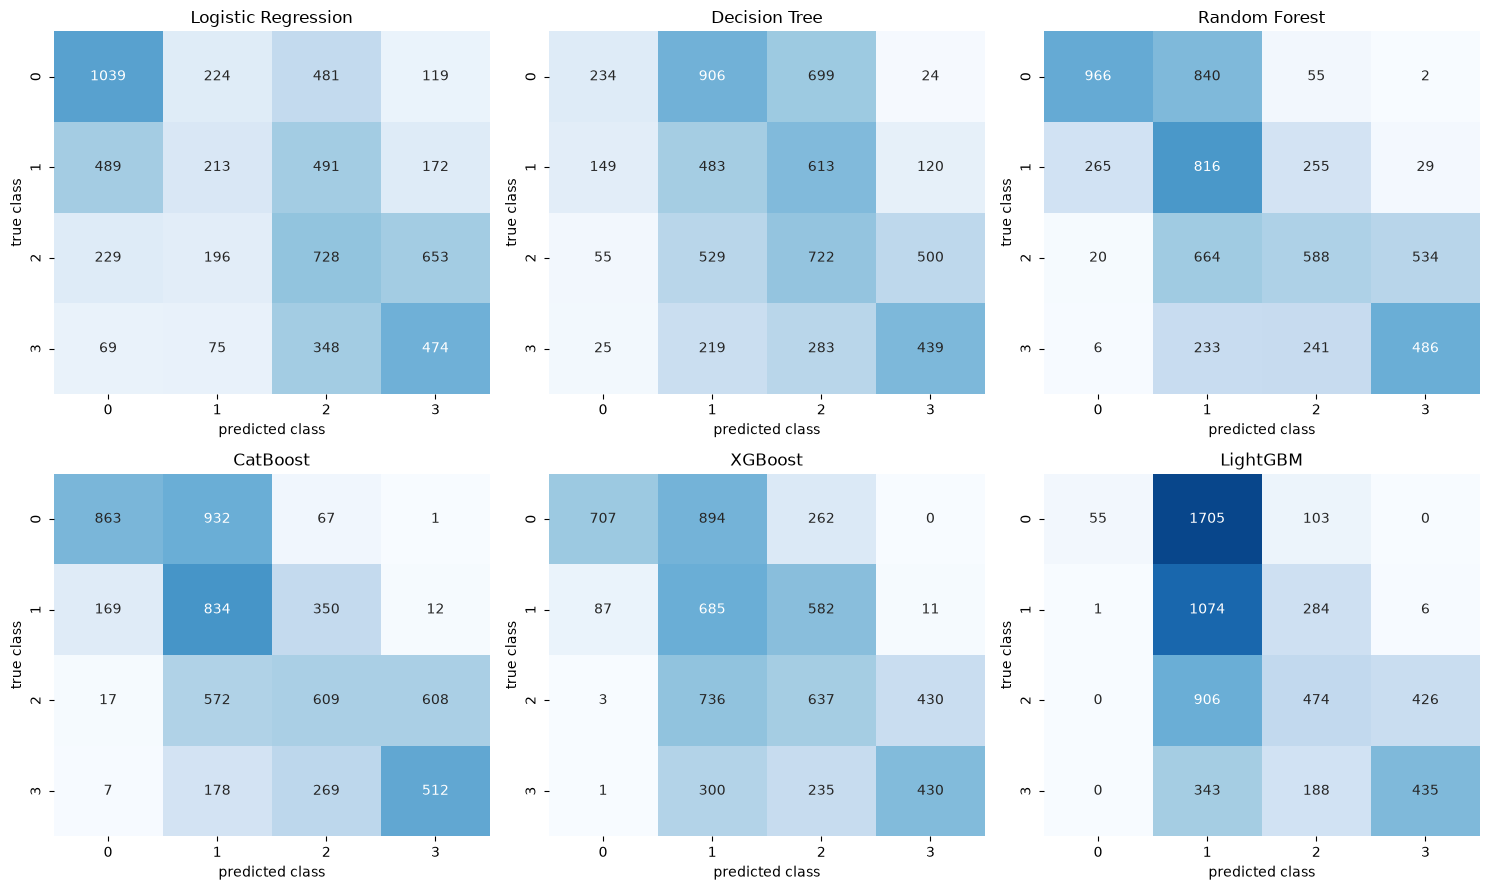

=== Confusion matrix summary (test set) ===
                     Accuracy  Avg_class_distance  Adjacent_error_%
Model                                                              
Logistic Regression     0.409               0.813            67.710
Decision Tree           0.313               0.886            72.295
Random Forest           0.476               0.583            89.027
CatBoost                0.470               0.579            91.138
XGBoost                 0.410               0.686            83.705
LightGBM                0.340               0.736            88.592


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

supervised_models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dt_clf,
    'Random Forest': rf_clf,
    'CatBoost': catboost_clf,
    'XGBoost': xgb_clf,
    'LightGBM': lgbm_clf,
}
severity_classes = [0, 1, 2, 3]
dist_matrix = np.abs(np.subtract.outer(severity_classes, severity_classes))  # |true-pred| class distance, 4x4

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

confusion_mats = {}
summary_rows = []
for ax, (name, model) in zip(axes, supervised_models.items()):
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_severity_test, y_pred_test, labels=severity_classes)
    confusion_mats[name] = cm

    row_pct = cm / cm.sum(axis=1, keepdims=True)  # normalize by true-class size for the color scale
    sns.heatmap(row_pct, annot=cm, fmt='d', cmap='Blues', vmin=0, vmax=1, cbar=False,
                xticklabels=severity_classes, yticklabels=severity_classes, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('predicted class')
    ax.set_ylabel('true class')

    total = cm.sum()
    errors = total - np.trace(cm)
    adjacent_errors = int((cm * (dist_matrix == 1)).sum())  # off-by-one-class errors, e.g. 1 predicted as 2
    summary_rows.append({
        'Model': name,
        'Accuracy': np.trace(cm) / total,
        'Avg_class_distance': (cm * dist_matrix).sum() / total,  # 0 = perfect, higher = worse ordinal miss
        'Adjacent_error_%': (adjacent_errors / errors * 100) if errors else np.nan,
    })

plt.tight_layout()
plt.show()

confusion_summary_df = pd.DataFrame(summary_rows).set_index('Model').round(3)
print("=== Confusion matrix summary (test set) ===")
print(confusion_summary_df)

In [ ]:
# Most frequent misclassification per model, and a short overall summary
print("=== Most frequent misclassification per model (test set) ===")
for name, cm in confusion_mats.items():
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    if cm_off.sum() == 0:
        print(f"{name:20s}: no misclassifications")
        continue
    i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
    true_cls, pred_cls = severity_classes[i], severity_classes[j]
    print(f"{name:20s}: true class {true_cls} -> predicted class {pred_cls}  "
          f"({cm_off[i, j]} cycles, {cm_off[i, j] / cm[i].sum():.1%} of all true-class-{true_cls} cycles)")

best_acc_model = confusion_summary_df['Accuracy'].idxmax()
best_dist_model = confusion_summary_df['Avg_class_distance'].idxmin()
avg_adjacent_pct = confusion_summary_df['Adjacent_error_%'].mean()

print("\n=== Summary ===")
print(f"- Highest test accuracy: {best_acc_model} "
      f"({confusion_summary_df.loc[best_acc_model, 'Accuracy']:.1%})")
print(f"- Mildest mistakes on average (lowest true-vs-predicted class distance): {best_dist_model} "
      f"({confusion_summary_df.loc[best_dist_model, 'Avg_class_distance']:.3f} classes off, on average)")
print(f"- Across all 6 models, {avg_adjacent_pct:.1f}% of misclassifications on average land on an "
      "ADJACENT severity class (e.g. 1<->2) rather than a distant one (e.g. 0<->3) -- "
      "consistent with the ordinal nature of the target, and less costly in practice than a distant miss.")

=== Most frequent misclassification per model (test set) ===
Logistic Regression : true class 2 -> predicted class 3  (653 cycles, 36.2% of all true-class-2 cycles)
Decision Tree       : true class 0 -> predicted class 1  (906 cycles, 48.6% of all true-class-0 cycles)
Random Forest       : true class 0 -> predicted class 1  (840 cycles, 45.1% of all true-class-0 cycles)
CatBoost            : true class 0 -> predicted class 1  (932 cycles, 50.0% of all true-class-0 cycles)
XGBoost             : true class 0 -> predicted class 1  (894 cycles, 48.0% of all true-class-0 cycles)
LightGBM            : true class 0 -> predicted class 1  (1705 cycles, 91.5% of all true-class-0 cycles)

=== Summary ===
- Highest test accuracy: Random Forest (47.6%)
- Mildest mistakes on average (lowest true-vs-predicted class distance): CatBoost (0.579 classes off, on average)
- Across all 6 models, 82.1% of misclassifications on average land on an ADJACENT severity class (e.g. 1<->2) rather than a distant one 

## Sanity Check 1: Anomaly Score Orientation

For each unsupervised detector, verify that a **higher score = more anomalous**
(i.e. scores should rise as the true severity class goes 0 -> 1 -> 2 -> 3), and
auto-correct (negate) any detector where that isn't the case.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# All detectors were scored on X_val above (iso_score, ecod_score, copod_score,
# lof_score, ae_score) and X_val/y_val share the same row order, so we can pair
# each raw score array with the ground-truth severity class (0-3) for that row.
raw_anomaly_scores = {
    'Isolation Forest': iso_score,
    'ECOD': ecod_score,
    'COPOD': copod_score,
    'LOF': lof_score,
    'Autoencoder': ae_score,
}
severity_val = y_severity_val.values  # 0=healthy .. 3=severe, aligned with X_val rows

# Orientation check: Spearman correlation between raw score and true severity.
# A positive correlation means "higher score -> higher severity" (correct
# orientation already). A negative correlation means the score is inverted
# (e.g. some libraries report "normality" instead of "abnormality"), so we
# negate it before any further evaluation.
oriented_scores = {}
orientation_rows = []
for name, raw_score in raw_anomaly_scores.items():
    raw_score = np.asarray(raw_score)
    corr, _ = spearmanr(raw_score, severity_val)
    flipped = corr < 0
    oriented_scores[name] = -raw_score if flipped else raw_score
    orientation_rows.append({
        'Detector': name,
        'Spearman_corr_raw_score_vs_severity': round(corr, 4),
        'Negated': flipped,
    })

orientation_df = pd.DataFrame(orientation_rows)
print("=== Orientation check (score vs. true severity class) ===")
print(orientation_df.to_string(index=False))

# Per-class mean / median / std of the (correctly oriented) anomaly score
print("\n=== Anomaly score distribution by original class (0/1/2/3), per detector ===")
class_stats = {}
for name, score in oriented_scores.items():
    stats = (pd.DataFrame({'score': score, 'class': severity_val})
             .groupby('class')['score'].agg(['mean', 'median', 'std', 'count']))
    class_stats[name] = stats
    print(f"\n--- {name} ---")
    print(stats.round(4))

=== Orientation check (score vs. true severity class) ===
        Detector  Spearman_corr_raw_score_vs_severity  Negated
Isolation Forest                               0.5544    False
            ECOD                               0.3774    False
           COPOD                               0.3363    False
             LOF                               0.5353    False
     Autoencoder                               0.5319    False

=== Anomaly score distribution by original class (0/1/2/3), per detector ===

--- Isolation Forest ---
         mean  median     std  count
class                               
0     -0.0246 -0.0263  0.0170   1626
1     -0.0173 -0.0197  0.0265   1142
2      0.0027  0.0005  0.0252   1911
3      0.0202  0.0150  0.0345   1321

--- ECOD ---
          mean   median      std  count
class                                  
0      89.5488  88.9010   8.0794   1626
1      92.7948  91.9015   8.3352   1142
2      97.0732  96.8192   9.1324   1911
3      99.2385  98.1942 

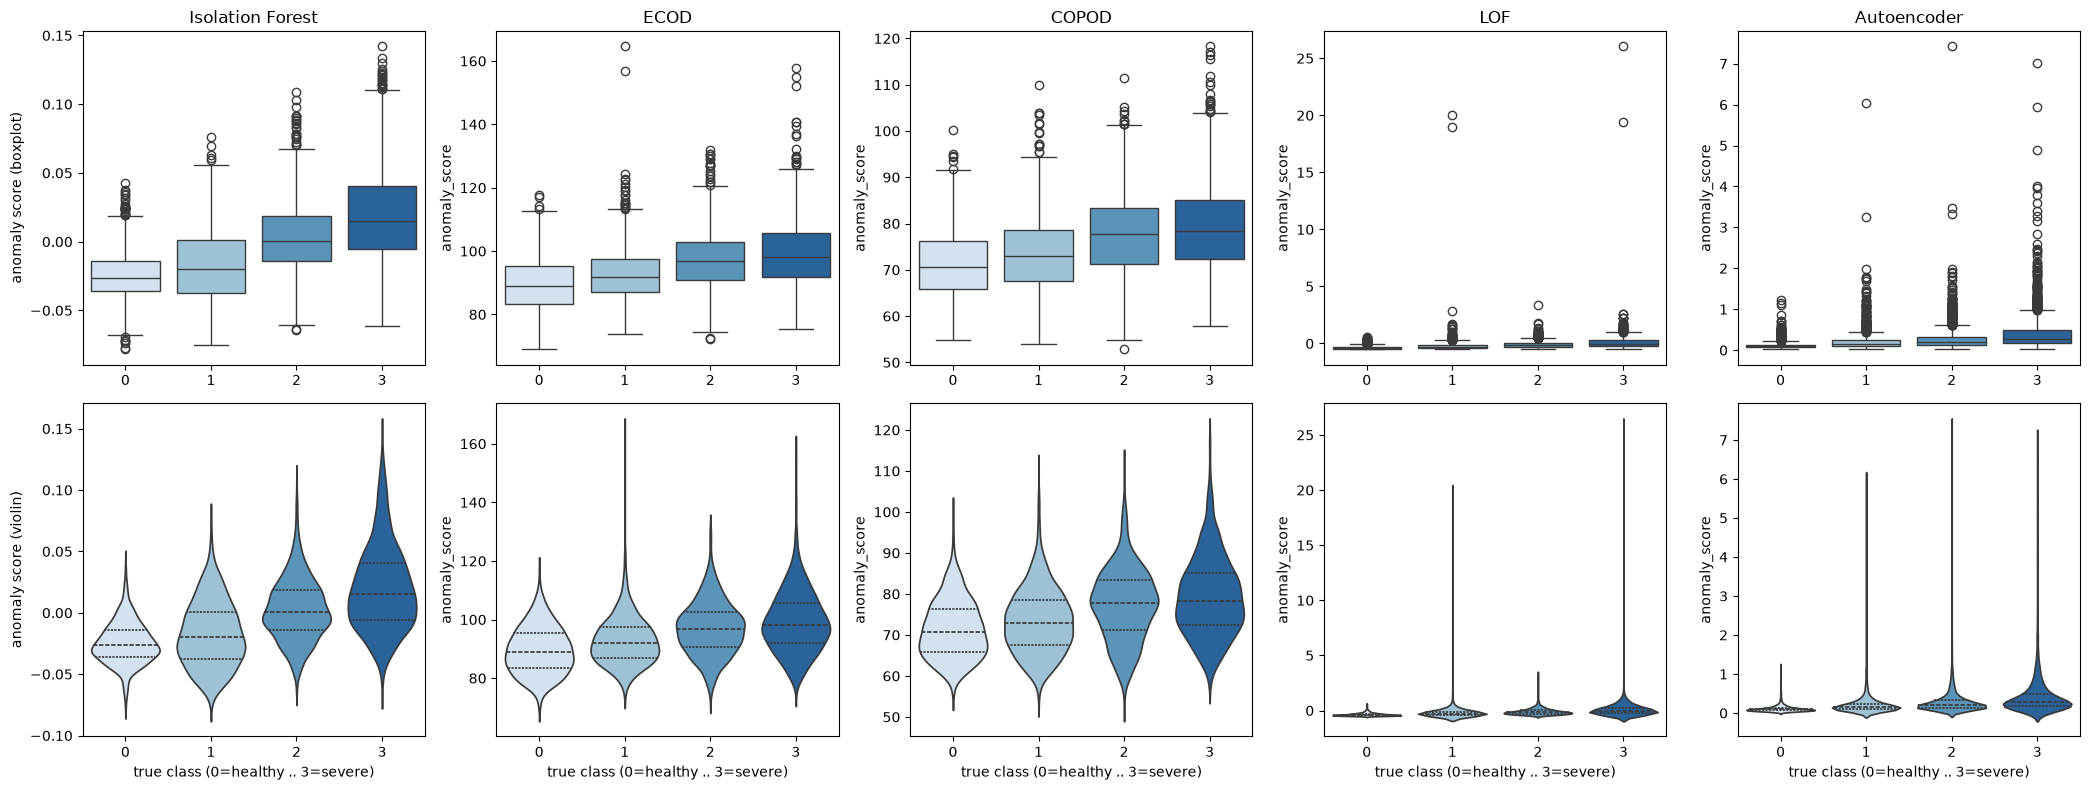

In [ ]:
# Visualize each detector's (oriented) anomaly score against the true severity class.
# Classes 0-3 are ordinal (increasing degradation), so a single sequential hue
# (light -> dark) is used instead of unordered categorical colors.
sev_palette = sns.color_palette('Blues', n_colors=4)

fig, axes = plt.subplots(2, len(oriented_scores), figsize=(4.2 * len(oriented_scores), 8))
for col_idx, (name, score) in enumerate(oriented_scores.items()):
    plot_df = pd.DataFrame({'anomaly_score': score, 'class': severity_val})

    ax_box = axes[0, col_idx]
    sns.boxplot(data=plot_df, x='class', y='anomaly_score', hue='class',
                palette=sev_palette, legend=False, ax=ax_box)
    ax_box.set_title(name)
    ax_box.set_xlabel('')

    ax_violin = axes[1, col_idx]
    sns.violinplot(data=plot_df, x='class', y='anomaly_score', hue='class',
                    palette=sev_palette, legend=False, inner='quartile', ax=ax_violin)
    ax_violin.set_xlabel('true class (0=healthy .. 3=severe)')

axes[0, 0].set_ylabel('anomaly score (boxplot)')
axes[1, 0].set_ylabel('anomaly score (violin)')
plt.tight_layout()
plt.show()

In [ ]:
# Does the mean anomaly score increase monotonically with degradation (0->1->2->3)?
monotonic_report = {}
print("=== Monotonicity of mean anomaly score across classes 0->1->2->3 ===")
for name, stats in class_stats.items():
    means = stats['mean']
    is_monotonic = means.is_monotonic_increasing
    monotonic_report[name] = is_monotonic
    print(f"{name:18s} means={means.round(4).to_dict()}  monotonic_increasing={is_monotonic}")

    if not is_monotonic:
        # Explain the most likely cause: a class with very few validation rows
        # (noisy mean) or classes 1-3 not being separable in the healthy-only
        # feature space the detector was fit on.
        counts = stats['count']
        sparse_classes = counts[counts < 30].index.tolist()
        if sparse_classes:
            print(f"    -> likely noisy: classes {sparse_classes} have <30 samples in val")
        else:
            print("    -> not a sample-size artifact: detector genuinely does not "
                  "separate these severity levels in feature space")

=== Monotonicity of mean anomaly score across classes 0->1->2->3 ===
Isolation Forest   means={0: -0.0246, 1: -0.0173, 2: 0.0027, 3: 0.0202}  monotonic_increasing=True
ECOD               means={0: 89.5488, 1: 92.7948, 2: 97.0732, 3: 99.2385}  monotonic_increasing=True
COPOD              means={0: 71.3895, 1: 73.4831, 2: 77.268, 3: 79.2887}  monotonic_increasing=True
LOF                means={0: -0.3447, 1: -0.1707, 2: -0.0898, 3: 0.1039}  monotonic_increasing=True
Autoencoder        means={0: 0.1167, 1: 0.2277, 2: 0.2853, 3: 0.4361}  monotonic_increasing=True


## Sanity Check 2: Are Validation / Test Harder Than Train?

For each of the 9 target columns, compare the class-0/1/2/3 proportions across
train / validation / test. If val or test carry relatively more unhealthy
(class 1/2/3) samples than train, that's a plausible explanation for the
val/test metric drop seen in the supervised results above.

In [ ]:
# Class counts + percentages of each target column, separately for train/val/test.
# y_train, y_val, y_test already hold the 9 target columns for their respective split.
split_labels = {'train': y_train, 'val': y_val, 'test': y_test}

comparison_rows = []
for col in target:
    for split_name, y_split in split_labels.items():
        counts = y_split[col].value_counts().sort_index()
        pcts = y_split[col].value_counts(normalize=True).sort_index() * 100
        for cls in counts.index:
            comparison_rows.append({
                'Target': col, 'Class': cls, 'Split': split_name,
                'Count': int(counts[cls]), 'Percent': pcts[cls],
            })
comparison_df = pd.DataFrame(comparison_rows)

# One comparison table: rows = (Target, Class), columns = train/val/test %.
comparison_table = (comparison_df
                     .pivot_table(index=['Target', 'Class'], columns='Split', values='Percent')
                     .reindex(columns=['train', 'val', 'test'])
                     .fillna(0.0)
                     .round(2))
print("=== Class % by target, train vs. val vs. test ===")
print(comparison_table.to_string())

=== Class % by target, train vs. val vs. test ===
Split                         train    val   test
Target                 Class                     
Barrel_Heater_State    0      86.47  85.47  89.20
                       1       7.44   5.80   7.13
                       2       4.25   6.22   2.55
                       3       1.84   2.52   1.12
Clamp_Unit_State       0      90.22  83.80  92.60
                       1       5.65   8.40   1.22
                       2       3.04   4.98   4.08
                       3       1.10   2.82   2.10
Cooling_System_State   0      83.80  84.38  80.43
                       1       9.28   7.77  11.23
                       2       5.12   5.57   6.32
                       3       1.81   2.28   2.02
Ejector_System_State   0      80.77  79.13  76.67
                       1      10.38  14.22  11.22
                       2       6.24   4.88   8.52
                       3       2.61   1.77   3.60
Hopper_State           0      88.78  70.67  80.37


In [ ]:
# Flag (Target, Class) combinations where val or test has a HIGHER percentage of an
# unhealthy class (1/2/3) than train -- evidence that val/test are "harder" splits.
diff_table = comparison_table.copy()
diff_table['val_minus_train'] = diff_table['val'] - diff_table['train']
diff_table['test_minus_train'] = diff_table['test'] - diff_table['train']

is_unhealthy_class = diff_table.index.get_level_values('Class') != 0
harder_val_mask = is_unhealthy_class & (diff_table['val_minus_train'] > 0)
harder_test_mask = is_unhealthy_class & (diff_table['test_minus_train'] > 0)

print("=== Target/class combos where VAL has relatively MORE unhealthy samples than train ===")
print(diff_table[harder_val_mask][['train', 'val', 'val_minus_train']].to_string())

print("\n=== Target/class combos where TEST has relatively MORE unhealthy samples than train ===")
print(diff_table[harder_test_mask][['train', 'test', 'test_minus_train']].to_string())

=== Target/class combos where VAL has relatively MORE unhealthy samples than train ===
Split                         train    val  val_minus_train
Target                 Class                               
Barrel_Heater_State    2       4.25   6.22             1.97
                       3       1.84   2.52             0.68
Clamp_Unit_State       1       5.65   8.40             2.75
                       2       3.04   4.98             1.94
                       3       1.10   2.82             1.72
Cooling_System_State   2       5.12   5.57             0.45
                       3       1.81   2.28             0.47
Ejector_System_State   1      10.38  14.22             3.84
Hopper_State           1       9.10  12.02             2.92
                       2       1.58  12.93            11.35
                       3       0.55   4.38             3.83
Hydraulic_System_State 1       7.66  14.23             6.57
                       2       5.86  10.02             4.16
             

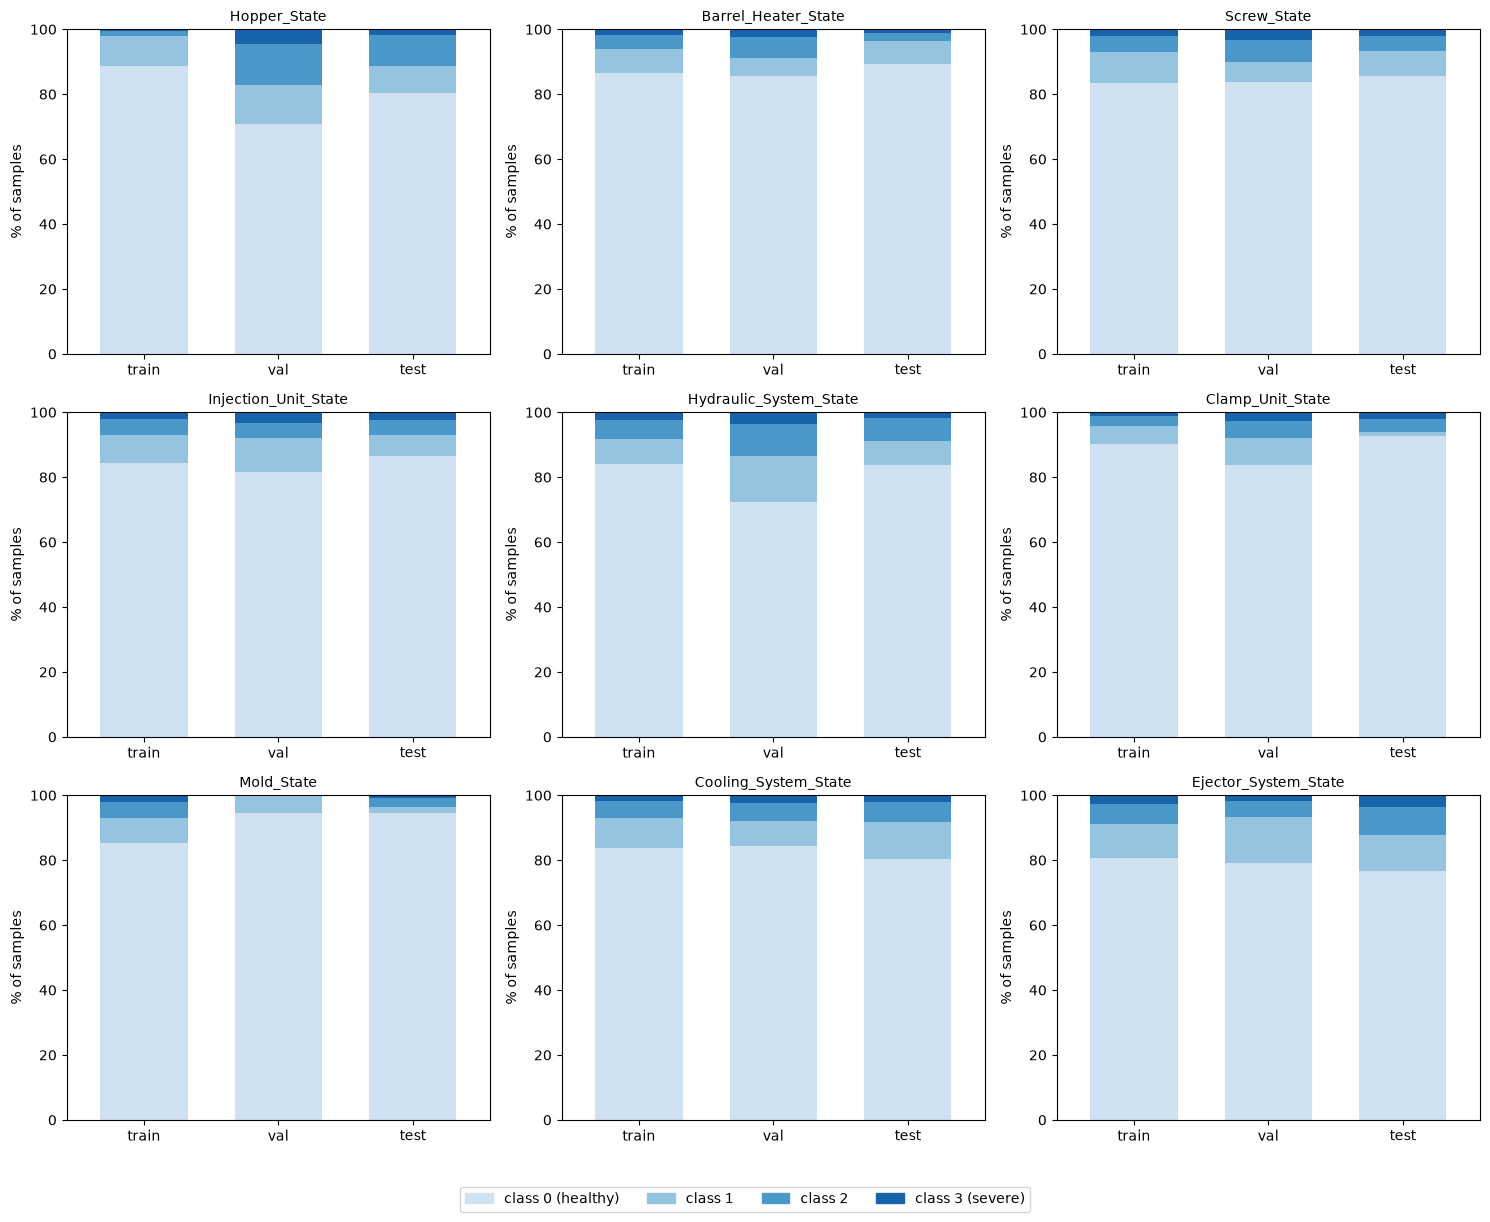

In [ ]:
# Stacked bar chart per target: class-% composition of train vs. val vs. test.
# Classes are ordinal severity (0-3) so a single sequential hue (light->dark) is
# used, with each class number fixed to the same color in every panel/legend.
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
full_class_palette = sns.color_palette('Blues', n_colors=4)  # fixed color per class 0-3, reused below

for ax, col in zip(axes, target):
    pct_data = (comparison_df[comparison_df['Target'] == col]
                .pivot(index='Split', columns='Class', values='Percent')
                .reindex(index=['train', 'val', 'test'], columns=[0, 1, 2, 3])  # fixed class set/order even if a class is absent for this target
                .fillna(0.0))

    pct_data.plot(kind='bar', stacked=True, ax=ax, color=full_class_palette,
                   width=0.65, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('% of samples')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=0)

# One shared legend for the ordinal class encoding used in every panel.
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in full_class_palette]
fig.legend(handles, ['class 0 (healthy)', 'class 1', 'class 2', 'class 3 (severe)'],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Summary

In [ ]:
print("=" * 78)
print("SUMMARY")
print("=" * 78)

# (a) Anomaly score orientation
n_flipped = int(orientation_df['Negated'].sum())
non_monotonic = [name for name, ok in monotonic_report.items() if not ok]

print("\n(a) Anomaly score orientation:")
if n_flipped == 0:
    print("    All 5 detectors were already correctly oriented "
          "(higher score = more anomalous).")
else:
    flipped_names = orientation_df.loc[orientation_df['Negated'], 'Detector'].tolist()
    print(f"    {n_flipped} detector(s) had inverted scores and were negated: {flipped_names}")

if non_monotonic:
    print(f"    Scores do NOT increase monotonically with degradation (0->1->2->3) for: {non_monotonic}")
    print("    (see per-detector explanation printed above -- either small-sample noise")
    print("     at some class, or the detector genuinely can't separate those severities)")
else:
    print("    For every detector, mean anomaly score increases monotonically 0->1->2->3.")

# (b) Validation / test difficulty vs. train
n_harder_val = int(harder_val_mask.sum())
n_harder_test = int(harder_test_mask.sum())
total_combos = len(target) * 3  # 3 non-healthy classes per target, upper bound

print("\n(b) Validation / test vs. train difficulty:")
print(f"    Validation has a higher unhealthy-class % than train in "
      f"{n_harder_val} (target, class) combinations.")
print(f"    Test has a higher unhealthy-class % than train in "
      f"{n_harder_test} (target, class) combinations.")
if n_harder_val > 0 or n_harder_test > 0:
    print("    -> Validation and/or test skew toward MORE unhealthy samples than train,")
    print("       consistent with the val/test metric drop seen in the supervised results.")
else:
    print("    -> No evidence that val/test are harder than train from class balance alone.")

# (c) Other potential issues
print("\n(c) Potential issues detected:")
issues_found = False
if non_monotonic:
    issues_found = True
    print(f"    - Non-monotonic detectors ({non_monotonic}) may not rank severity reliably "
          "beyond binary healthy-vs-anomalous.")
if n_harder_val > 0 or n_harder_test > 0:
    issues_found = True
    print("    - Train/val/test class distributions differ per-target -- the split is time-based "
          "per mold (chronological), so later cycles (val/test) naturally carry more wear.")
print(f"    - Novelty detectors were fit on only {healthy_mask.mean():.1%} of training rows "
      "(the fully-healthy subset) -- a small, and possibly non-representative, training sample.")
if not issues_found:
    print("    - None beyond the small healthy-only training subset noted above.")

SUMMARY

(a) Anomaly score orientation:
    All 5 detectors were already correctly oriented (higher score = more anomalous).
    For every detector, mean anomaly score increases monotonically 0->1->2->3.

(b) Validation / test vs. train difficulty:
    Validation has a higher unhealthy-class % than train in 18 (target, class) combinations.
    Test has a higher unhealthy-class % than train in 13 (target, class) combinations.
    -> Validation and/or test skew toward MORE unhealthy samples than train,
       consistent with the val/test metric drop seen in the supervised results.

(c) Potential issues detected:
    - Train/val/test class distributions differ per-target -- the split is time-based per mold (chronological), so later cycles (val/test) naturally carry more wear.
    - Novelty detectors were fit on only 27.3% of training rows (the fully-healthy subset) -- a small, and possibly non-representative, training sample.
